## Lab 04: KEYPOINT DETECTION

1. Khai báo thư viện ảnh


(np.float64(-0.5), np.float64(625.5), np.float64(314.5), np.float64(-0.5))

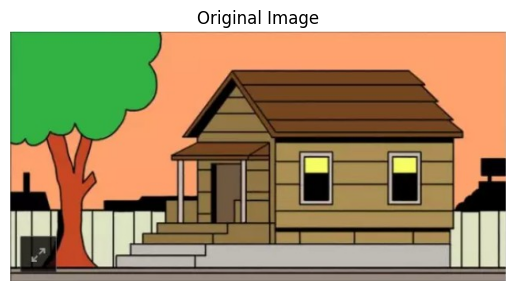

In [ ]:
import numpy as np
import cv2
from matplotlib import pyplot as NguyenHuynhAnhTu

# đọc ảnh
img = cv2.imread('hinh1.jpg')

# hiển thị ảnh đúng màu (BGR -> RGB)
NguyenHuynhAnhTu.imshow(img[:,:,::-1])
NguyenHuynhAnhTu.title("Original Image")
NguyenHuynhAnhTu.axis("off")

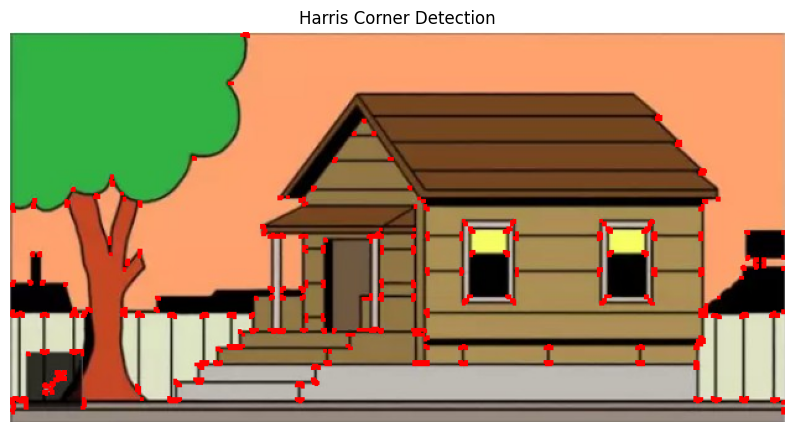

In [ ]:
#2Harris Corner Detection
import numpy as np
import cv2
from matplotlib import pyplot as NguyenHuynhAnhTu

# 1. Đọc ảnh và chuyển sang ảnh xám
img = cv2.imread('hinh1.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 2. Harris Corner Detection yêu cầu kiểu dữ liệu float32
gray = np.float32(gray)

# 3. Áp dụng Harris Corner Detection
# Tham số: (ảnh, blockSize, ksize, k)
dst = cv2.cornerHarris(gray, 2, 3, 0.04)

# Giãn nở kết quả để làm nổi bật các điểm góc
dst = cv2.dilate(dst, None)

# 4. Ngưỡng để hiển thị các góc (đánh dấu bằng màu đỏ)
img_harris = img.copy()
img_harris[dst > 0.01 * dst.max()] = [0, 0, 255]

# 5. Hiển thị kết quả
NguyenHuynhAnhTu.figure(figsize=(10, 6))
NguyenHuynhAnhTu.imshow(img_harris[:,:,::-1])
NguyenHuynhAnhTu.title("Harris Corner Detection")
NguyenHuynhAnhTu.axis("off")
NguyenHuynhAnhTu.show()

3. Band-pass filtering (Difference of Gaussian)

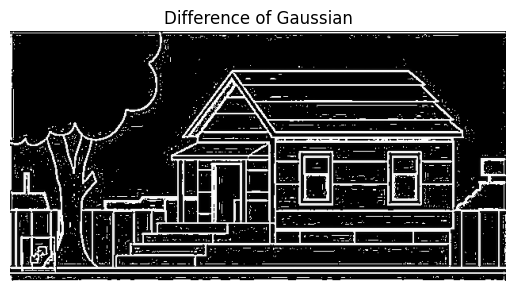

In [ ]:
# 3. Difference of Gaussian
img_gray = cv2.imread('hinh1.jpg', 0)
blur1 = cv2.GaussianBlur(img_gray, (5, 5), 1)
blur2 = cv2.GaussianBlur(img_gray, (5, 5), 2)
dog = blur1 - blur2

NguyenHuynhAnhTu.imshow(dog, cmap='gray')
NguyenHuynhAnhTu.title("Difference of Gaussian")
NguyenHuynhAnhTu.axis("off")
NguyenHuynhAnhTu.show()

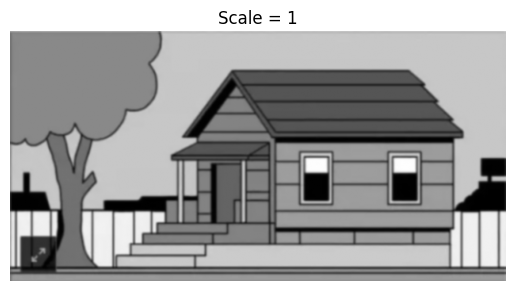

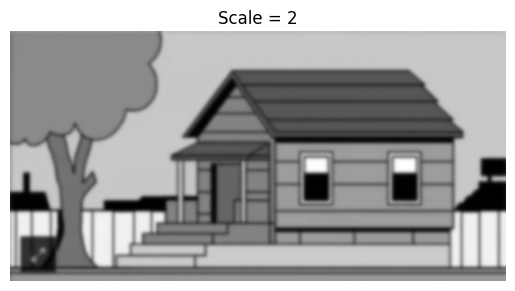

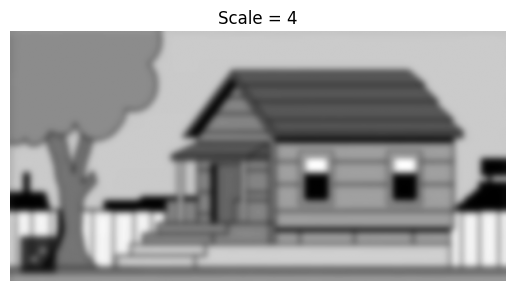

In [ ]:
# 4. Automatic Scale Selection
img_gray = cv2.imread('hinh1.jpg', 0)
scales = [1, 2, 4]
for s in scales:
    blur = cv2.GaussianBlur(img_gray, (0, 0), s)
    NguyenHuynhAnhTu.imshow(blur, cmap='gray')
    NguyenHuynhAnhTu.title(f"Scale = {s}")
    NguyenHuynhAnhTu.axis("off")
    NguyenHuynhAnhTu.show()

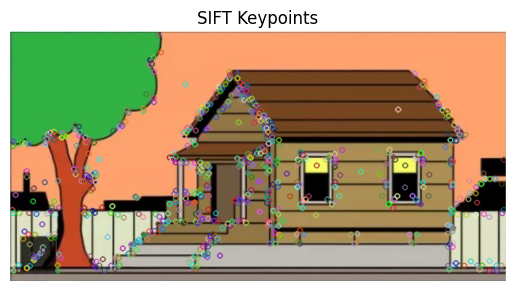

In [ ]:
# 5. Scale Invariant Detection (SIFT)
img_sift = cv2.imread('hinh1.jpg')
gray_sift = cv2.cvtColor(img_sift, cv2.COLOR_BGR2GRAY)
sift = cv2.SIFT_create()
kp, des = sift.detectAndCompute(gray_sift, None)
img_kp = cv2.drawKeypoints(img_sift, kp, None)

NguyenHuynhAnhTu.imshow(img_kp[:,:,::-1])
NguyenHuynhAnhTu.title("SIFT Keypoints")
NguyenHuynhAnhTu.axis("off")
NguyenHuynhAnhTu.show()

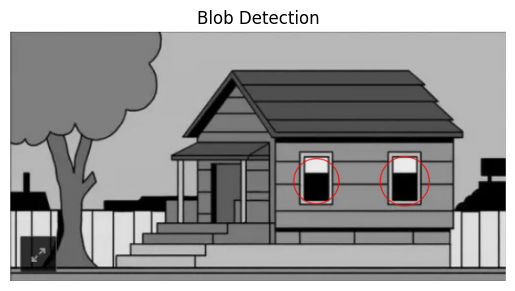

In [ ]:
# 6. Scale-space Blob Detector
img_blob_src = cv2.imread('hinh1.jpg', 0)
detector = cv2.SimpleBlobDetector_create()
keypoints = detector.detect(img_blob_src)
img_blob = cv2.drawKeypoints(img_blob_src, keypoints, np.array([]), (255, 0, 0), cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

NguyenHuynhAnhTu.imshow(img_blob, cmap='gray')
NguyenHuynhAnhTu.title("Blob Detection")
NguyenHuynhAnhTu.axis("off")
NguyenHuynhAnhTu.show()

In [ ]:
# 7. Bag-of-Words Detection (Descriptors Info)
print("Number of SIFT descriptors:", des.shape)

Number of SIFT descriptors: (766, 128)


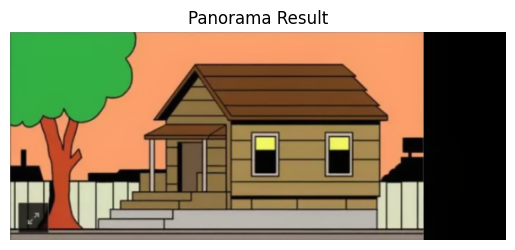

In [ ]:
# 8. Ghép ảnh Image Panoramas (Simulated)
img_base = cv2.imread('hinh1.jpg')
rows, cols = img_base.shape[:2]
shift = int(cols * 0.2)
img_left = img_base.copy()
img_right = np.zeros_like(img_base)
img_right[:, :-shift] = img_base[:, shift:]

stitcher = cv2.Stitcher_create()
status, pano = stitcher.stitch([img_left, img_right])
if status == cv2.Stitcher_OK:
    NguyenHuynhAnhTu.imshow(pano[:,:,::-1])
    NguyenHuynhAnhTu.title("Panorama Result")
    NguyenHuynhAnhTu.axis("off")
    NguyenHuynhAnhTu.show()

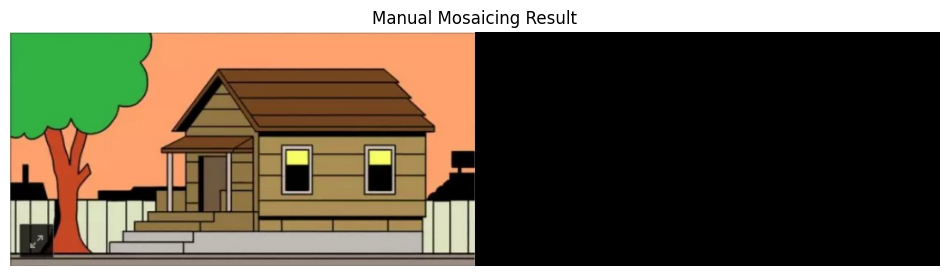

In [ ]:

import cv2
import numpy as np
from matplotlib import pyplot as NguyenHuynhAnhTu

def manual_stitch(img1, img2):
    # 1. Chuyển sang ảnh xám
    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

    # 2. Tìm điểm đặc trưng bằng SIFT
    sift = cv2.SIFT_create()
    kp1, des1 = sift.detectAndCompute(gray1, None)
    kp2, des2 = sift.detectAndCompute(gray2, None)

    # 3. Khớp các điểm đặc trưng (BFMatcher)
    bf = cv2.BFMatcher()
    matches = bf.knnMatch(des1, des2, k=2)

    # 4. Lọc các khớp tốt theo tỉ lệ Lowe's ratio
    good = []
    for m, n in matches:
        if m.distance < 0.7 * n.distance:
            good.append(m)

    if len(good) > 10:
        src_pts = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
        dst_pts = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)

        # 5. Tìm ma trận Homography
        H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

        # 6. Ghép ảnh (Warp perspective)
        width = img1.shape[1] + img2.shape[1]
        height = img1.shape[0]
        result = cv2.warpPerspective(img1, H, (width, height))
        result[0:img2.shape[0], 0:img2.shape[1]] = img2

        return result
    else:
        return None

# Load images
img1_mos = cv2.imread('hinh1.jpg')
img2_mos = cv2.imread('hinh2.jpg')

if img1_mos is None or img2_mos is None:
    print("Vui lòng kiểm tra lại file hinh1.jpg và hinh2.jpg")
else:
    pano = manual_stitch(img1_mos, img2_mos)
    if pano is not None:
        NguyenHuynhAnhTu.figure(figsize=(12, 8))
        NguyenHuynhAnhTu.imshow(pano[:,:,::-1])
        NguyenHuynhAnhTu.title("Manual Mosaicing Result")
        NguyenHuynhAnhTu.axis('off')
        NguyenHuynhAnhTu.show()
    else:
        print("Không tìm đủ điểm tương đồng để ghép ảnh.")

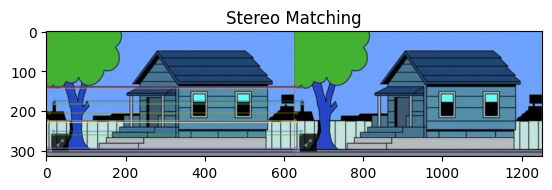

In [ ]:
# 10. Wide base-line stereo (Matching)
img1 = cv2.imread('hinh1.jpg')
img2 = cv2.imread('hinh1.jpg') # Giả lập
sift_st = cv2.SIFT_create()
kp1, des1 = sift_st.detectAndCompute(img1, None)
kp2, des2 = sift_st.detectAndCompute(img2, None)
bf = cv2.BFMatcher()
matches = bf.knnMatch(des1, des2, k=2)
good = [m for m, n in matches if m.distance < 0.75 * n.distance]
img_matches = cv2.drawMatches(img1, kp1, img2, kp2, good[:20], None, flags=2)
NguyenHuynhAnhTu.imshow(img_matches)
NguyenHuynhAnhTu.title("Stereo Matching")
NguyenHuynhAnhTu.show()

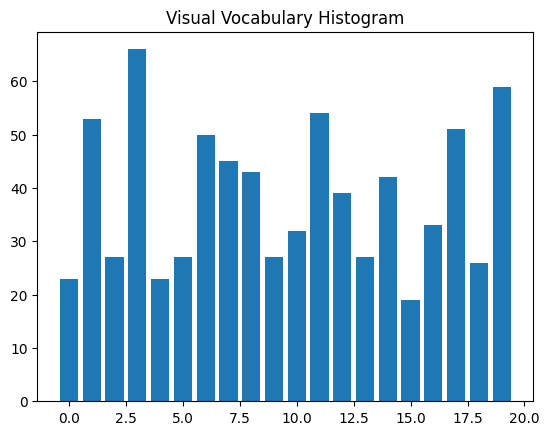

In [ ]:
from sklearn.cluster import KMeans
# 11. CBIR
num_clusters = 20
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
visual_words = kmeans.fit_predict(des)
hist, _ = np.histogram(visual_words, bins=range(num_clusters + 1))
NguyenHuynhAnhTu.bar(range(num_clusters), hist)
NguyenHuynhAnhTu.title("Visual Vocabulary Histogram")
NguyenHuynhAnhTu.show()

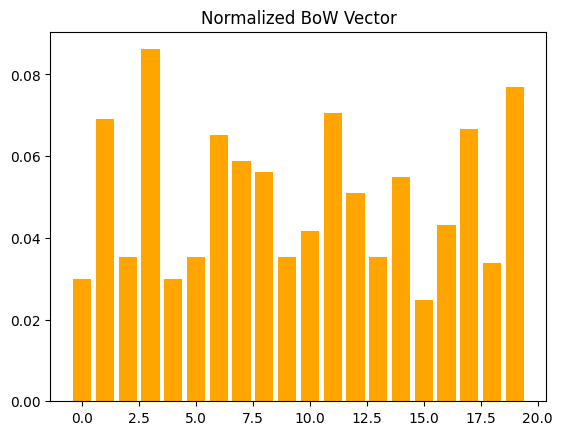

In [ ]:
# 12. Bag-of-word Normalized Histogram
bow_vec = hist.astype("float32") / (hist.sum() + 1e-6)
NguyenHuynhAnhTu.bar(range(num_clusters), bow_vec, color='orange')
NguyenHuynhAnhTu.title("Normalized BoW Vector")
NguyenHuynhAnhTu.show()